In [1]:
import numpy as np
import os
from tqdm import tqdm
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'svg'

In [2]:
plt.rcParams.update({'font.size': 16})
plt.rcParams.update({'lines.linewidth': 2})

# EH Self Acceleration In Uniform Electric Field

In [3]:
L = 60 * np.pi
nx = 4000
dx = L / (nx - 1)

vmax_e = 10  # 速度最大值
nv_e = 2000
dv_e = 2 * vmax_e / (nv_e - 1)

vmax_i = 0.52185  # 速度最大值
nv_i = 2000
dv_i = 2 * vmax_i / (nv_i - 1)

x = np.linspace(0, L, num=nx, endpoint=True)
ve = np.linspace(-vmax_e, vmax_e, num=nv_e, endpoint=True)
vi = np.linspace(-vmax_i, vmax_i, num=nv_i, endpoint=True)

dt = 0.05
max_steps = 20000

In [4]:
path0 = r"E:\工作\我的论文\2026CHSinAppliedEField\simulations\uniformE_E00004"
path1 = r"E:\工作\我的论文\2026CHSinAppliedEField\simulations\uniformE_E00006"
path2 = r"E:\工作\我的论文\2026CHSinAppliedEField\simulations\uniformE_E00008"
path3 = r"E:\工作\我的论文\2026CHSinAppliedEField\simulations\uniformE_E0001"
path4 = r"E:\工作\我的论文\2026CHSinAppliedEField\simulations\uniformE_E00012"

path5 = r"E:\工作\我的论文\2026CHSinAppliedEField\simulations\uniformE_E00008_t105"
path6 = r"E:\工作\我的论文\2026CHSinAppliedEField\simulations\uniformE_E00008_t205"
path7 = r"E:\工作\我的论文\2026CHSinAppliedEField\simulations\uniformE_E00008"
path8 = r"E:\工作\我的论文\2026CHSinAppliedEField\simulations\uniformE_E00008_t405"
path9 = r"E:\工作\我的论文\2026CHSinAppliedEField\simulations\uniformE_E00008_t505"

path_list_Ea = [path0, path1, path2, path3, path4]
path_list_T  = [path5, path6, path7, path8, path9]
t = np.linspace(0, max_steps, num = max_steps + 1, endpoint=True) * dt

In [5]:
E_a_list = [0.0004, 0.0006, 0.0008, 0.001, 0.0012]
T_list  = [100, 200, 300, 400, 500]
phi_list = []
v_EH_final_Ea = []
v_EH_final_T = []
v_EH_mean_start = 12000
v_EH_mean_end = 19001

In [6]:
for p in tqdm(path_list_Ea):
    phi = np.loadtxt(os.path.join(p, "Phi_evolution"))
    phi_peaks_x = np.argmax(phi, axis=0) * dx
    phi_peaks_x_test = phi_peaks_x[v_EH_mean_start:v_EH_mean_end]
    t_fit = t[v_EH_mean_start:v_EH_mean_end]
    velocity_fit, _ = np.polyfit(t_fit, phi_peaks_x_test, 1)
    v_EH_final_Ea.append(velocity_fit)

for p in tqdm(path_list_T):
    phi = np.loadtxt(os.path.join(p, "Phi_evolution"))
    phi_peaks_x = np.argmax(phi, axis=0) * dx
    phi_peaks_x_test = phi_peaks_x[v_EH_mean_start:v_EH_mean_end]
    t_fit = t[v_EH_mean_start:v_EH_mean_end]
    velocity_fit, _ = np.polyfit(t_fit, phi_peaks_x_test, 1)
    v_EH_final_T.append(velocity_fit)

100%|██████████| 5/5 [00:32<00:00,  6.48s/it]


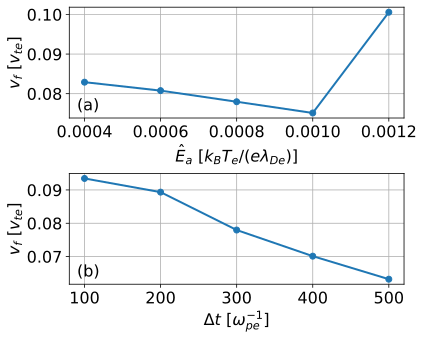

In [ ]:
fig, (ax1, ax2) = plt.subplots(figsize=(6, 5), nrows=2, ncols=1)

ax1.plot(E_a_list, v_EH_final_Ea, "o-")
ax1.set_xlabel(r"$\hat{E}_a~[k_BT_e/(e\lambda_{De})]$")
ax1.set_ylabel(r"$v_{f}~[v_{te}]$")
ax1.grid()

ax2.plot(T_list, v_EH_final_T, "o-")
ax2.set_xlabel(r"$\Delta t~[\omega_{pe}^{-1}]$")
ax2.set_ylabel(r"$v_{f}~[v_{te}]$")
ax2.grid()

ax1.text(0.023, 0.07, "(a)", transform=ax1.transAxes)
ax2.text(0.023, 0.07, "(b)", transform=ax2.transAxes)

fig.align_ylabels()
plt.subplots_adjust(hspace=0.5)

# plt.savefig("fig4_uniformE_vfinal_vs_Ea_T.pdf", bbox_inches='tight',dpi=600)
plt.show()

In [8]:
print(v_EH_final_Ea)

[0.08290536523708845, 0.08076959098209291, 0.07795878757716923, 0.07512413811325837, 0.10057313510700755]


In [9]:
print(v_EH_final_T)

[0.0934562614632656, 0.08934388961432935, 0.07795878757716923, 0.07010838179761084, 0.06318874869373775]
